In [8]:
import os
from PIL import Image, ImageDraw, ImageFont

def merge_and_label_coins():
    # 1. 定义路径和目标币种
    folder_path = r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs"
    # 定义排版顺序 (0,0) (0,1) (1,0) (1,1)
    coins = ["BTC", "ETH", "XRP", "SOL"] 
    
    image_dict = {}
    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    
    if not os.path.exists(folder_path):
        print(f"❌ 找不到文件夹: {folder_path}")
        return

    # 2. 筛选并匹配图片
    for file in os.listdir(folder_path):
        lower_file = file.lower()
        if 'total' in lower_file and lower_file.endswith(valid_extensions):
            for coin in coins:
                if coin.lower() in lower_file:
                    image_dict[coin] = os.path.join(folder_path, file)
                    break
    
    if not image_dict:
        print("❌ 文件夹中没有找到同时包含 'total' 和币种名称的图片！")
        return
        
    print(f"✅ 找到 {len(image_dict)} 个币种的图片，准备进行 2x2 拼接与标注...")

    # 3. 读取图片并统一尺寸 (以找到的第一张图为准)
    images = {}
    base_size = None
    for coin in coins:
        if coin in image_dict:
            img = Image.open(image_dict[coin])
            if base_size is None:
                base_size = img.size
            if img.size != base_size:
                img = img.resize(base_size, Image.Resampling.LANCZOS)
            images[coin] = img

    if not images:
        return

    base_width, base_height = base_size
    
    # 4. 设置画布
    # 动态计算标题所需的留白高度 (占原始图片高度的 8% 左右)
    title_padding = int(base_height * 0.08) 
    
    # 2x2 画布总尺寸 (宽度 x 2, 高度包含每次额外加的标题留白 x 2)
    target_width = base_width * 2
    target_height = (base_height + title_padding) * 2
    
    merged_image = Image.new('RGB', (target_width, target_height), 'white')
    draw = ImageDraw.Draw(merged_image)
    
    # 5. 设置字体 (尝试加载适合论文的 Times New Roman 或 Arial)
    font_size = int(title_padding * 0.5) # 字体大小随图片分辨率动态调整
    try:
        font = ImageFont.truetype("times.ttf", font_size)
    except:
        try:
            font = ImageFont.truetype("arial.ttf", font_size)
        except:
            print("⚠️ 未在系统中找到常用字体，使用默认字体。")
            font = ImageFont.load_default()

    # 6. 开始拼图与标注
    for index, coin in enumerate(coins):
        if coin not in images:
            print(f"⚠️ 缺失 {coin} 的图片，跳过该位置。")
            continue
            
        img = images[coin]
        row = index // 2
        col = index % 2
        
        # 计算图片粘贴的左上角坐标 (需把头部的 title_padding 留出来)
        x = col * base_width
        y = row * (base_height + title_padding) + title_padding
        
        # 粘贴图片本体
        merged_image.paste(img, (x, y))
        
        # 绘制文本标题
        title_text = f"({chr(97+index)}) {coin}" # 生成 (a) BTC, (b) ETH 等格式
        
        # 计算文字的宽高，以保证水平居中
        try:
            bbox = font.getbbox(title_text)
            text_width = bbox[2] - bbox[0]
            text_height = bbox[3] - bbox[1]
        except AttributeError: # 兼容老版本 Pillow
            text_width, text_height = draw.textsize(title_text, font=font)
            
        text_x = x + (base_width - text_width) // 2
        text_y = y - title_padding + (title_padding - text_height) // 2
        
        # 画字 (黑色)
        draw.text((text_x, text_y), title_text, fill="black", font=font)

    # 7. 保存最终结果
    save_path = os.path.join(folder_path, "Merged_Coins_cummupnl_total.png")
    merged_image.save(save_path)
    print(f"\n🎉 合并及标注成功！带标题的 2x2 图片已保存至: \n{save_path}")

if __name__ == "__main__":
    merge_and_label_coins()

✅ 找到 4 个币种的图片，准备进行 2x2 拼接与标注...

🎉 合并及标注成功！带标题的 2x2 图片已保存至: 
D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\Merged_Coins_cummupnl_total.png


In [2]:
import os
from PIL import Image, ImageDraw, ImageFont

def merge_and_label_coins():
    # 1. 定义路径和目标币种
    folder_path = r"D:\Desktop\LSTM_TRACKING\LSTM论文v4\figs"
    # 定义排版顺序 (0,0) (0,1) (1,0) (1,1)
    coins = ["BTC", "ETH", "XRP", "SOL"] 
    
    image_dict = {}
    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    
    if not os.path.exists(folder_path):
        print(f"❌ 找不到文件夹: {folder_path}")
        return

    # 2. 筛选并匹配图片
    for file in os.listdir(folder_path):
        lower_file = file.lower()
        if 'each' in lower_file and lower_file.endswith(valid_extensions):
            for coin in coins:
                if coin.lower() in lower_file:
                    image_dict[coin] = os.path.join(folder_path, file)
                    break
    
    if not image_dict:
        print("❌ 文件夹中没有找到同时包含 'each' 和币种名称的图片！")
        return
        
    print(f"✅ 找到 {len(image_dict)} 个币种的图片，准备进行 2x2 拼接与标注...")

    # 3. 读取图片并统一尺寸 (以找到的第一张图为准)
    images = {}
    base_size = None
    for coin in coins:
        if coin in image_dict:
            img = Image.open(image_dict[coin])
            if base_size is None:
                base_size = img.size
            if img.size != base_size:
                img = img.resize(base_size, Image.Resampling.LANCZOS)
            images[coin] = img

    if not images:
        return

    base_width, base_height = base_size
    
    # 4. 设置画布
    # 动态计算标题所需的留白高度 (占原始图片高度的 8% 左右)
    title_padding = int(base_height * 0.08) 
    
    # 2x2 画布总尺寸 (宽度 x 2, 高度包含每次额外加的标题留白 x 2)
    target_width = base_width * 2
    target_height = (base_height + title_padding) * 2
    
    merged_image = Image.new('RGB', (target_width, target_height), 'white')
    draw = ImageDraw.Draw(merged_image)
    
    # 5. 设置字体 (尝试加载适合论文的 Times New Roman 或 Arial)
    font_size = int(title_padding * 0.5) # 字体大小随图片分辨率动态调整
    try:
        font = ImageFont.truetype("times.ttf", font_size)
    except:
        try:
            font = ImageFont.truetype("arial.ttf", font_size)
        except:
            print("⚠️ 未在系统中找到常用字体，使用默认字体。")
            font = ImageFont.load_default()

    # 6. 开始拼图与标注
    for index, coin in enumerate(coins):
        if coin not in images:
            print(f"⚠️ 缺失 {coin} 的图片，跳过该位置。")
            continue
            
        img = images[coin]
        row = index // 2
        col = index % 2
        
        # 计算图片粘贴的左上角坐标 (需把头部的 title_padding 留出来)
        x = col * base_width
        y = row * (base_height + title_padding) + title_padding
        
        # 粘贴图片本体
        merged_image.paste(img, (x, y))
        
        # 绘制文本标题
        title_text = f"({chr(97+index)}) {coin}" # 生成 (a) BTC, (b) ETH 等格式
        
        # 计算文字的宽高，以保证水平居中
        try:
            bbox = font.getbbox(title_text)
            text_width = bbox[2] - bbox[0]
            text_height = bbox[3] - bbox[1]
        except AttributeError: # 兼容老版本 Pillow
            text_width, text_height = draw.textsize(title_text, font=font)
            
        text_x = x + (base_width - text_width) // 2
        text_y = y - title_padding + (title_padding - text_height) // 2
        
        # 画字 (黑色)
        draw.text((text_x, text_y), title_text, fill="black", font=font)

    # 7. 保存最终结果
    save_path = os.path.join(folder_path, "Merged_Coins_cummupnl_each.png")
    merged_image.save(save_path)
    print(f"\n🎉 合并及标注成功！带标题的 2x2 图片已保存至: \n{save_path}")

if __name__ == "__main__":
    merge_and_label_coins()

✅ 找到 4 个币种的图片，准备进行 2x2 拼接与标注...

🎉 合并及标注成功！带标题的 2x2 图片已保存至: 
D:\Desktop\LSTM_TRACKING\LSTM论文v4\figs\Merged_Coins_cummupnl_each.png


In [5]:
import os
from PIL import Image, ImageDraw, ImageFont

def merge_and_label_coins():
    # 1. 定义路径和目标币种
    folder_path = r"D:\Desktop\LSTM_TRACKING\LSTM论文v4\figs"
    # 定义排版顺序 (0,0) (0,1) (1,0) (1,1)
    coins = ["BTC", "ETH", "XRP", "SOL"] 
    
    image_dict = {}
    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    
    if not os.path.exists(folder_path):
        print(f"❌ 找不到文件夹: {folder_path}")
        return

    # 2. 筛选并匹配图片
    for file in os.listdir(folder_path):
        lower_file = file.lower()
        if 'dis' in lower_file and lower_file.endswith(valid_extensions):
            for coin in coins:
                if coin.lower() in lower_file:
                    image_dict[coin] = os.path.join(folder_path, file)
                    break
    
    if not image_dict:
        print("❌ 文件夹中没有找到同时包含 'dis' 和币种名称的图片！")
        return
        
    print(f"✅ 找到 {len(image_dict)} 个币种的图片，准备进行 2x2 拼接与标注...")

    # 3. 读取图片并统一尺寸 (以找到的第一张图为准)
    images = {}
    base_size = None
    for coin in coins:
        if coin in image_dict:
            img = Image.open(image_dict[coin])
            if base_size is None:
                base_size = img.size
            if img.size != base_size:
                img = img.resize(base_size, Image.Resampling.LANCZOS)
            images[coin] = img

    if not images:
        return

    base_width, base_height = base_size
    
    # 4. 设置画布
    # 动态计算标题所需的留白高度 (占原始图片高度的 8% 左右)
    title_padding = int(base_height * 0.08) 
    
    # 2x2 画布总尺寸 (宽度 x 2, 高度包含每次额外加的标题留白 x 2)
    target_width = base_width * 2
    target_height = (base_height + title_padding) * 2
    
    merged_image = Image.new('RGB', (target_width, target_height), 'white')
    draw = ImageDraw.Draw(merged_image)
    
    # 5. 设置字体 (尝试加载适合论文的 Times New Roman 或 Arial)
    font_size = int(title_padding * 0.5) # 字体大小随图片分辨率动态调整
    try:
        font = ImageFont.truetype("times.ttf", font_size)
    except:
        try:
            font = ImageFont.truetype("arial.ttf", font_size)
        except:
            print("⚠️ 未在系统中找到常用字体，使用默认字体。")
            font = ImageFont.load_default()

    # 6. 开始拼图与标注
    for index, coin in enumerate(coins):
        if coin not in images:
            print(f"⚠️ 缺失 {coin} 的图片，跳过该位置。")
            continue
            
        img = images[coin]
        row = index // 2
        col = index % 2
        
        # 计算图片粘贴的左上角坐标 (需把头部的 title_padding 留出来)
        x = col * base_width
        y = row * (base_height + title_padding) + title_padding
        
        # 粘贴图片本体
        merged_image.paste(img, (x, y))
        
        # 绘制文本标题
        title_text = f"({chr(97+index)}) {coin}" # 生成 (a) BTC, (b) ETH 等格式
        
        # 计算文字的宽高，以保证水平居中
        try:
            bbox = font.getbbox(title_text)
            text_width = bbox[2] - bbox[0]
            text_height = bbox[3] - bbox[1]
        except AttributeError: # 兼容老版本 Pillow
            text_width, text_height = draw.textsize(title_text, font=font)
            
        text_x = x + (base_width - text_width) // 2
        text_y = y - title_padding + (title_padding - text_height) // 2
        
        # 画字 (黑色)
        draw.text((text_x, text_y), title_text, fill="black", font=font)

    # 7. 保存最终结果
    save_path = os.path.join(folder_path, "Merged_Coins_perTradeDistribution.png")
    merged_image.save(save_path)
    print(f"\n🎉 合并及标注成功！带标题的 2x2 图片已保存至: \n{save_path}")

if __name__ == "__main__":
    merge_and_label_coins()

✅ 找到 4 个币种的图片，准备进行 2x2 拼接与标注...

🎉 合并及标注成功！带标题的 2x2 图片已保存至: 
D:\Desktop\LSTM_TRACKING\LSTM论文v4\figs\Merged_Coins_perTradeDistribution.png


In [2]:
import os
from PIL import Image

# 你的文件夹路径（直接用你给的路径）
folder = r"D:\Desktop\LSTM_TRACKING\LSTM论文v4\figs"

# 需要处理的币种列表
coins = ["eth", "btc", "xrp", "sol"]

# 遍历处理每一种币
for coin in coins:
    # 拼接两张输入图片路径
    img1_path = os.path.join(folder, f"{coin}_margin1.png")
    img2_path = os.path.join(folder, f"{coin}_margin2.png")
    
    # 检查文件是否存在
    if not os.path.exists(img1_path) or not os.path.exists(img2_path):
        print(f"⚠️  {coin} 缺少图片，跳过...")
        continue

    # 打开图片
    img1 = Image.open(img1_path)
    img2 = Image.open(img2_path)

    # 上下合并：宽度取最大，高度相加
    new_width = max(img1.width, img2.width)
    new_height = img1.height + img2.height
    combined = Image.new("RGB", (new_width, new_height))

    # 粘贴图片（上 + 下）
    combined.paste(img1, (0, 0))
    combined.paste(img2, (0, img1.height))

    # 输出路径
    output_path = os.path.join(folder, f"labelmargin_{coin}.png")
    
    # 保存
    combined.save(output_path, dpi=(300, 300))  # 高清300dpi
    print(f"✅ 已生成：{output_path}")

print("\n🎉 所有图片合并完成！")

✅ 已生成：D:\Desktop\LSTM_TRACKING\LSTM论文v4\figs\labelmargin_eth.png
✅ 已生成：D:\Desktop\LSTM_TRACKING\LSTM论文v4\figs\labelmargin_btc.png
✅ 已生成：D:\Desktop\LSTM_TRACKING\LSTM论文v4\figs\labelmargin_xrp.png
✅ 已生成：D:\Desktop\LSTM_TRACKING\LSTM论文v4\figs\labelmargin_sol.png

🎉 所有图片合并完成！


In [ ]:
# from PIL import Image
# import os

# # ===== 图片路径 =====
# image_paths = [
#     r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_eth.png",
#     r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_sol.png",
#     r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_xrp.png",
#     r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_btc.png"
# ]

# # ===== 读取图片 =====
# images = [Image.open(p) for p in image_paths]

# # ===== 统一宽度（取最大宽度）=====
# max_width = max(img.width for img in images)

# # ===== 按比例缩放 =====
# resized_images = []
# total_height = 0

# for img in images:
#     ratio = max_width / img.width
#     new_height = int(img.height * ratio)
#     resized = img.resize((max_width, new_height), Image.LANCZOS)

#     resized_images.append(resized)
#     total_height += new_height

# # ===== 创建画布 =====
# merged_image = Image.new("RGB", (max_width, total_height), color="white")

# # ===== 依次粘贴 =====
# y_offset = 0
# for img in resized_images:
#     merged_image.paste(img, (0, y_offset))
#     y_offset += img.height

# # ===== 输出路径 =====
# output_path = r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_on_winrate.png"

# # ===== 保存 =====
# merged_image.save(output_path)

# print(f"Saved merged image to:\n{output_path}")

Saved merged image to:
D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_on_winrate.png


In [10]:
import os
from PIL import Image

# ===== 图片路径 =====
image_paths = [
    r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_eth.png",
    r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_sol.png",
    r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_xrp.png",
    r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_btc.png"
]

# ===== 读取图片 =====
images = [Image.open(p) for p in image_paths]

# ===== 统一尺寸（以第一张图 ETH 为基准尺寸） =====
base_width, base_height = images[0].size

resized_images = []
for img in images:
    if img.size != (base_width, base_height):
        # 如果尺寸不一致，使用 LANCZOS 统一缩放到基准尺寸
        resized = img.resize((base_width, base_height), Image.Resampling.LANCZOS)
    else:
        resized = img
    resized_images.append(resized)

# ===== 计算 2x2 画布总尺寸 =====
# 宽度 = 单张图宽 * 2
# 高度 = 单张图高 * 2
target_width = base_width * 2
target_height = base_height * 2

# 创建一个白底的 2x2 大画布
merged_image = Image.new("RGB", (target_width, target_height), color="white")

# ===== 2x2 依次粘贴 =====
# 对应的象限索引排布：
# index 0 -> row 0, col 0 (左上 ETH)
# index 1 -> row 0, col 1 (右上 SOL)
# index 2 -> row 1, col 0 (左下 XRP)
# index 3 -> row 1, col 1 (右下 BTC)
for index, img in enumerate(resized_images):
    row = index // 2
    col = index % 2
    
    # 计算当前图片在画布上的左上角坐标 (x, y)
    x = col * base_width
    y = row * base_height
    
    # 粘贴图片
    merged_image.paste(img, (x, y))

# ===== 输出路径 =====
output_path = r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_on_winrate.png"

# ===== 保存 =====
merged_image.save(output_path)

print(f"🎉 2x2 成功合并！新图片已保存至:\n{output_path}")

🎉 2x2 成功合并！新图片已保存至:
D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\improve_on_winrate.png


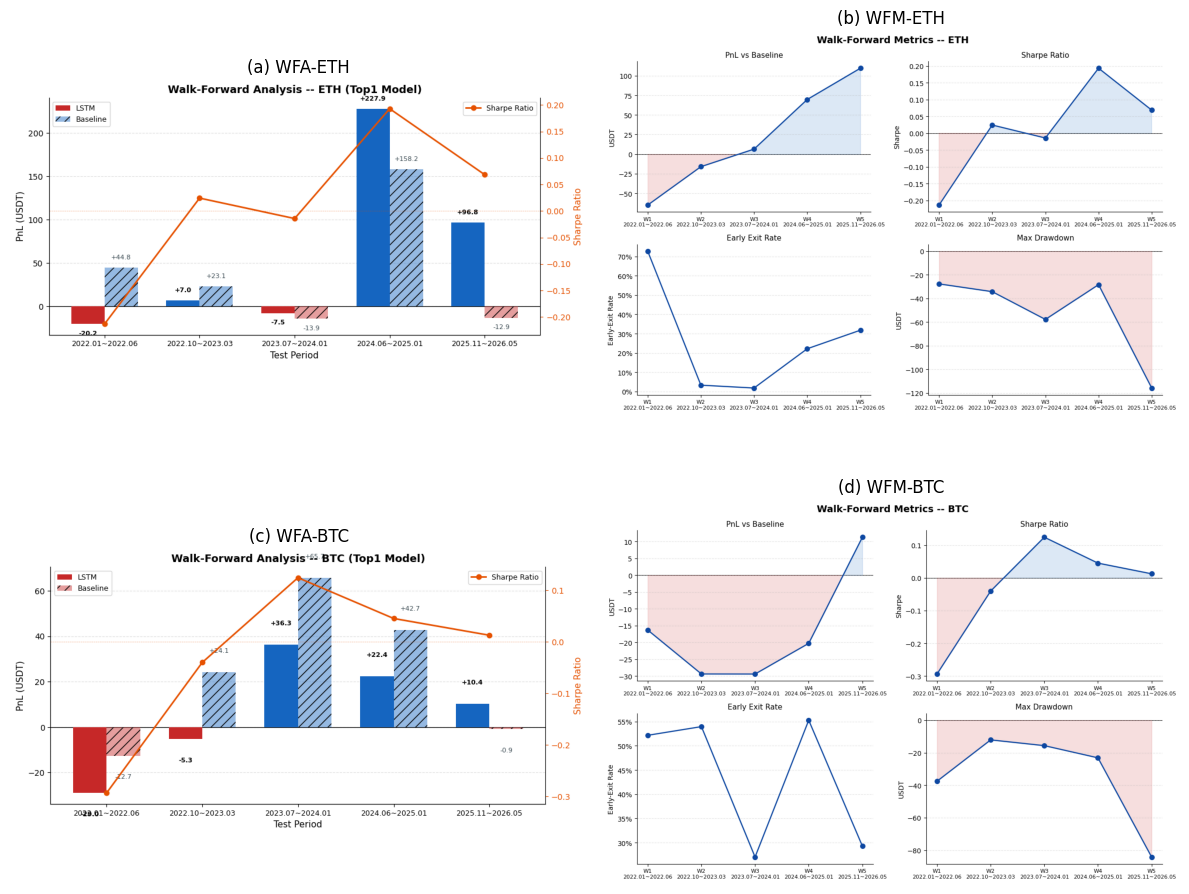

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

imgs = [
    (r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfa_eth.png", "(a) WFA-ETH"),
    (r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfm_eth.png", "(b) WFM-ETH"),
    (r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfa_btc.png", "(c) WFA-BTC"),
    (r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfm_btc.png", "(d) WFM-BTC"),
]

for ax, (img_path, title) in zip(axes.ravel(), imgs):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfa_wfm.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

图片已成功合并，并保存为当前目录下的: D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfa.png


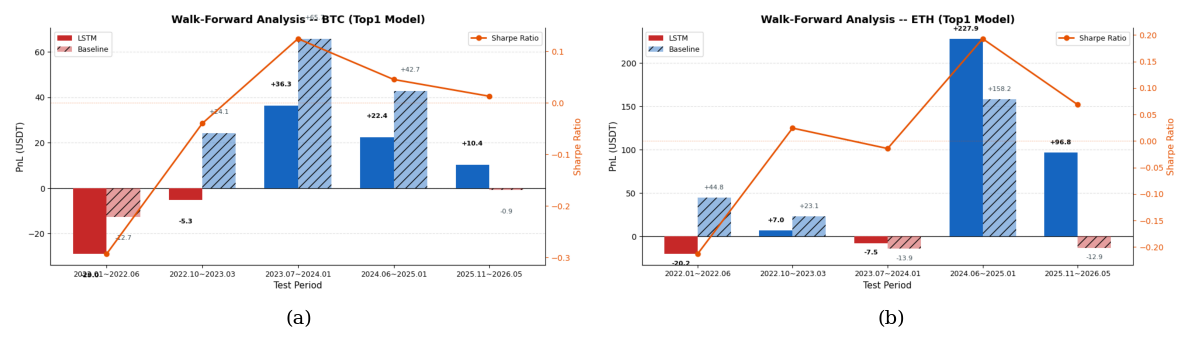

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. 定义图片路径 (使用 r 前缀确保 Windows 路径不会发生转义错误)
path_a = r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfa_btc.png"
path_b = r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfa_eth.png"

# 2. 读取图片
try:
    img_a = Image.open(path_a)
    img_b = Image.open(path_b)
except FileNotFoundError as e:
    print(f"找不到图片，请检查路径是否正确: {e}")
    exit()

# 3. 创建 1 行 2 列的画布
# figsize=(12, 5) 表示画布宽度为12，高度为5，您可以根据原图的宽高比按需微调
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 4. 绘制第一张图 (BTC)
axes[0].imshow(img_a)
axes[0].axis('off')  # 关闭坐标轴边框和刻度
# 在图片底部居中添加标号 (a)
axes[0].text(0.5, -0.05, '(a)', transform=axes[0].transAxes, 
             fontsize=14, ha='center', va='top', fontfamily='serif')

# 5. 绘制第二张图 (ETH)
axes[1].imshow(img_b)
axes[1].axis('off')  # 关闭坐标轴边框和刻度
# 在图片底部居中添加标号 (b)
axes[1].text(0.5, -0.05, '(b)', transform=axes[1].transAxes, 
             fontsize=14, ha='center', va='top', fontfamily='serif')

# 6. 自动调整子图间距，防止重叠
plt.tight_layout()

# 7. 保存为高分辨率图片 (dpi=300 满足大多数期刊要求，bbox_inches='tight' 去除多余白边)
output_name = r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfa.png"
plt.savefig(output_name, dpi=300, bbox_inches='tight', pad_inches=0.1)

print(f"图片已成功合并，并保存为当前目录下的: {output_name}")

图片已成功合并，并保存为当前目录下的: D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfa_roll.png


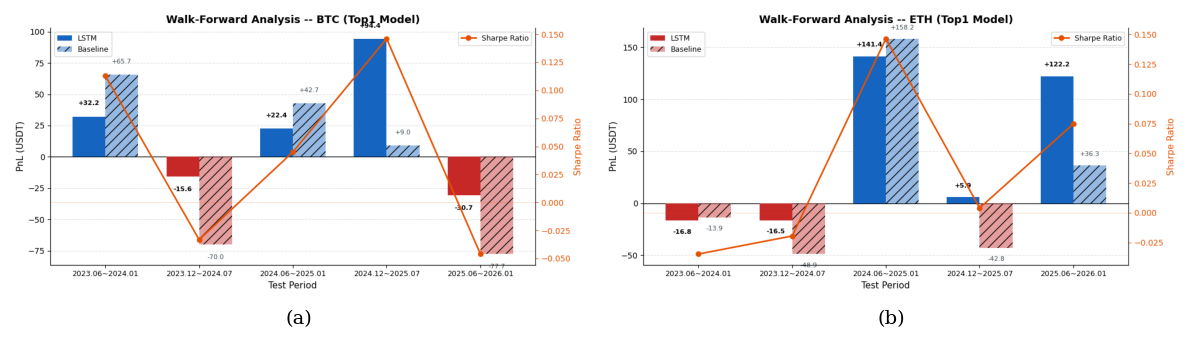

In [1]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. 定义图片路径 (使用 r 前缀确保 Windows 路径不会发生转义错误)
path_a = r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfa_btc_roll.png"
path_b = r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfa_eth_roll.png"

# 2. 读取图片
try:
    img_a = Image.open(path_a)
    img_b = Image.open(path_b)
except FileNotFoundError as e:
    print(f"找不到图片，请检查路径是否正确: {e}")
    exit()

# 3. 创建 1 行 2 列的画布
# figsize=(12, 5) 表示画布宽度为12，高度为5，您可以根据原图的宽高比按需微调
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 4. 绘制第一张图 (BTC)
axes[0].imshow(img_a)
axes[0].axis('off')  # 关闭坐标轴边框和刻度
# 在图片底部居中添加标号 (a)
axes[0].text(0.5, -0.05, '(a)', transform=axes[0].transAxes, 
             fontsize=14, ha='center', va='top', fontfamily='serif')

# 5. 绘制第二张图 (ETH)
axes[1].imshow(img_b)
axes[1].axis('off')  # 关闭坐标轴边框和刻度
# 在图片底部居中添加标号 (b)
axes[1].text(0.5, -0.05, '(b)', transform=axes[1].transAxes, 
             fontsize=14, ha='center', va='top', fontfamily='serif')

# 6. 自动调整子图间距，防止重叠
plt.tight_layout()

# 7. 保存为高分辨率图片 (dpi=300 满足大多数期刊要求，bbox_inches='tight' 去除多余白边)
output_name = r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\wfa_roll.png"
plt.savefig(output_name, dpi=300, bbox_inches='tight', pad_inches=0.1)

print(f"图片已成功合并，并保存为当前目录下的: {output_name}")

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 设置您的图片所在目录
base_dir = r"D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs"

# 需要处理的币种列表
coins = ['eth', 'btc', 'xrp', 'sol']

# 四个位置对应的图片前缀和编号
prefixes = ['vdraw', 'vpnl', 'vsharpe', 'vstop']
labels = ['(a)', '(b)', '(c)', '(d)']

for coin in coins:
    # 创建 2x2 的画布，figsize 可以根据您图片的比例适当调整
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs = axs.flatten()  # 展平以便于循环
    
    for i, prefix in enumerate(prefixes):
        # 拼接图片完整路径
        img_name = f"{prefix}_{coin}.png"
        img_path = os.path.join(base_dir, img_name)
        
        # 读取并显示图片
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            axs[i].imshow(img)
        else:
            print(f"警告: 找不到图片 {img_path}")
            axs[i].text(0.5, 0.5, 'Image Not Found', ha='center', va='center')
        
        # 关闭坐标轴显示
        axs[i].axis('off')
        
        # 在图片底部正中添加 (a) (b) (c) (d) 标签
        axs[i].text(0.5, -0.05, labels[i], transform=axs[i].transAxes, 
                    fontsize=16, ha='center', va='top', fontfamily='serif')

    # 调整布局以防止标签重叠
    plt.tight_layout()
    
    # 导出并保存合并后的图片
    output_name = f"merged_val_{coin}.png"
    output_path = os.path.join(base_dir, output_name)
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.close()
    
    print(f"成功合并并保存: {output_path}")

print("所有操作完成！")

成功合并并保存: D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\merged_val_eth.png
成功合并并保存: D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\merged_val_btc.png
成功合并并保存: D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\merged_val_xrp.png
成功合并并保存: D:\Desktop\LSTM_TRACKING\LSTM论文v6\figs\merged_val_sol.png
所有操作完成！
